In [ ]:
from pathlib import Path
import os

# Detect Colab
IN_COLAB = "COLAB_GPU" in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/Text_Mining_Project")
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT: /content/drive/MyDrive/Text_Mining_Project
RAW_DIR: /content/drive/MyDrive/Text_Mining_Project/data/raw
PROCESSED_DIR: /content/drive/MyDrive/Text_Mining_Project/data/processed


- We import libraries for text cleaning: regex, stopwords, spaCy for lemmatization.

In [ ]:
import pandas as pd
import re
import string
import nltk
import spacy

from nltk.corpus import stopwords
from pathlib import Path
from google.colab import drive
from tqdm import tqdm

tqdm.pandas()
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


- We load the version saved in notebook 01.

In [ ]:
import pandas as pd

df = pd.read_pickle(PROCESSED_DIR / "df_bbc.pkl")
df.head()




,text,label,length
0,Swap offer for pirated Windows XP\n\nComputer ...,tech,353
1,DS aims to touch gamers\n\nThe mobile gaming i...,tech,567
2,Digital guru floats sub-$100 PC\n\nNicholas Ne...,tech,464
3,The Force is strong in Battlefront\n\nThe warm...,tech,651
4,US blogger fired by her airline\n\nA US airlin...,tech,560


- Stopwords removed in BoW/TF-IDF models.
- spaCy used for lemmatization (reduction of words to the root).

In [ ]:
nltk.download('stopwords')

nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words("english"))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


"Strong" cleaning, suitable for TF-IDF and BoW:
- lowercase
- punctuation removal
- number removal
- lemmatization
- stopword removal

In [ ]:
def preprocess_for_bow(text):
    text = text.replace("\n", " ")
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    doc = nlp(text)
    tokens = []
    for token in doc:
        if token.lemma_ not in stop_words and token.is_alpha:
            tokens.append(token.lemma_)

    return " ".join(tokens)


BERT requires near-original text:
- NO lowercase, NO lemmatization, NO stopword removal.

Why? → It alters what BERT was trained on.

In [ ]:
def preprocess_for_bert(text):
    if not isinstance(text, str):
        return ""
    text = text.replace("\n", " ").strip()
    text = re.sub(r"\s+", " ", text)
    return text


We create two versions of the text:
- one for classic models
- one for BERT

In [ ]:
%%time
df["clean_text_bow"] = df["text"].progress_apply(preprocess_for_bow)
df["clean_text_bert"] = df["text"].progress_apply(preprocess_for_bert)

df[["text", "clean_text_bow", "clean_text_bert"]].head()


100%|██████████| 2232/2232 [00:00<00:00, 6497.21it/s]

CPU times: user 2min 44s, sys: 1.03 s, total: 2min 45s
Wall time: 2min 51s


,text,clean_text_bow,clean_text_bert
0,Swap offer for pirated Windows XP\n\nComputer ...,swap offer pirated window xp computer giant mi...,Swap offer for pirated Windows XP Computer gia...
1,DS aims to touch gamers\n\nThe mobile gaming i...,ds aim touch gamer mobile gaming industry set ...,DS aims to touch gamers The mobile gaming indu...
2,Digital guru floats sub-$100 PC\n\nNicholas Ne...,digital guru float sub pc nicholas negroponte ...,Digital guru floats sub-$100 PC Nicholas Negro...
3,The Force is strong in Battlefront\n\nThe warm...,force strong battlefront warm reception greet ...,The Force is strong in Battlefront The warm re...
4,US blogger fired by her airline\n\nA US airlin...,us blogger fire airline us airline attendant s...,US blogger fired by her airline A US airline a...


Let's compare how much preprocessing changes the length of texts.

In [ ]:
df["bow_length"] = df["clean_text_bow"].apply(lambda x: len(x.split()))
df["bert_length"] = df["clean_text_bert"].apply(lambda x: len(x.split()))

df[["bow_length", "bert_length"]].describe()


,bow_length,bert_length
count,2232.000000,2232.000000
mean,219.784050,383.553763
std,127.791333,237.978129
min,49.000000,89.000000
25%,142.000000,245.000000
50%,192.000000,331.000000
75%,270.000000,471.000000
max,2234.000000,4432.000000


Boxplot post-preprocessing

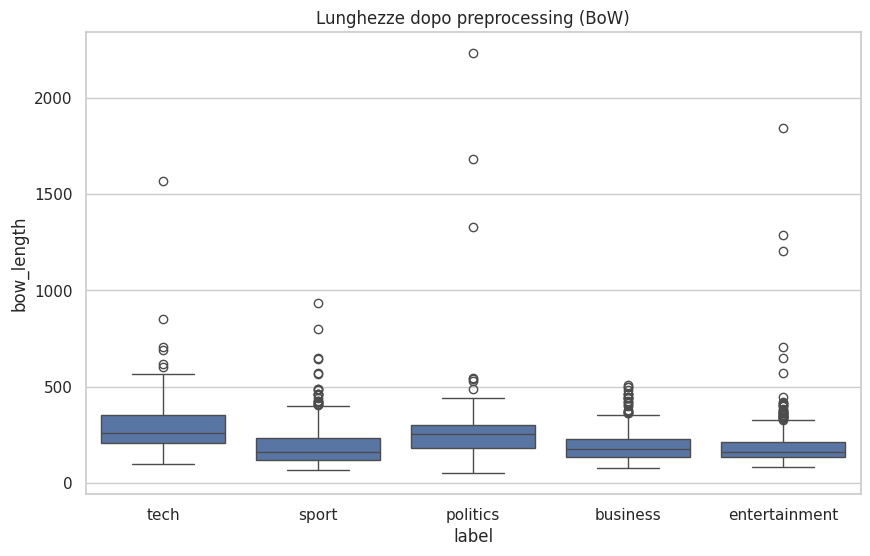

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="label", y="bow_length")
plt.title("Lengths after preprocessing (BoW)")
plt.show()


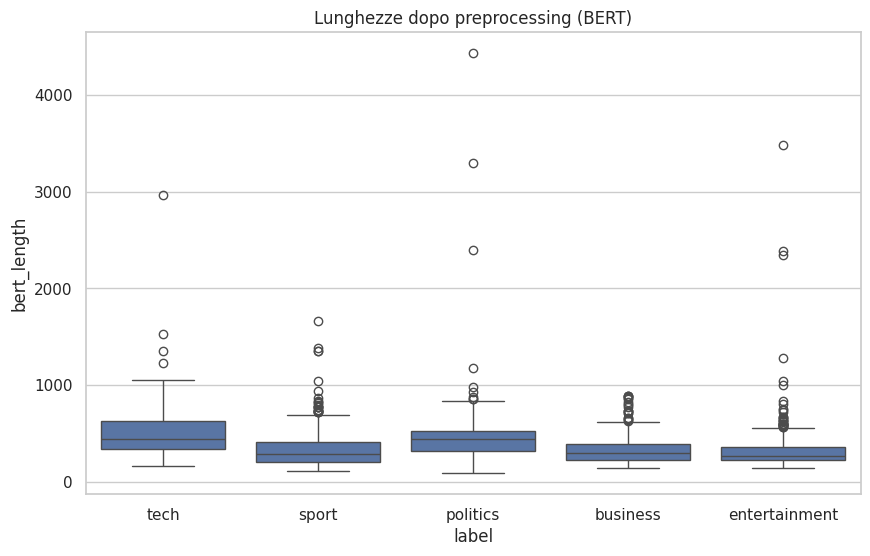

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="label", y="bert_length")
plt.title("Lengths after preprocessing (BERT)")
plt.show()


Saving preprocessed dataset

In [ ]:
output_path = PROCESSED_DIR / "df_bbc_preprocessed.pkl"
df.to_pickle(output_path)
print("Saved preprocessed dataset to:", output_path)



Saved preprocessed dataset to: /content/drive/MyDrive/Text_Mining_Project/data/processed/df_bbc_preprocessed.pkl
